In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [14]:
# Carregar o dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Dividir em treino (70%), validação (15%) e teste (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Normalizar os dados (importante para redes neurais)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Converter para tensores do PyTorch
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Criar DataLoaders
batch_size = 16
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Tamanho do treino: {len(X_train)}")
print(f"Tamanho da validação: {len(X_val)}")
print(f"Tamanho do teste: {len(X_test)}")

Tamanho do treino: 105
Tamanho da validação: 22
Tamanho do teste: 23


In [15]:
# Definir a arquitetura da MLP
class IrisMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(IrisMLP, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

In [16]:
def train_model(hidden_dim, lr, num_epochs, train_loader, val_loader):
    input_dim = 4
    output_dim = 3
    model = IrisMLP(input_dim, hidden_dim, output_dim)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validação
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

    return model, train_losses, val_losses

def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    y_pred = []
    y_true = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
            y_pred.extend(predicted.numpy())
            y_true.extend(y_batch.numpy())
            
    accuracy = 100 * correct / total
    return accuracy, y_true, y_pred

Treinando configuração: {'hidden_dim': 8, 'lr': 0.01, 'epochs': 50}


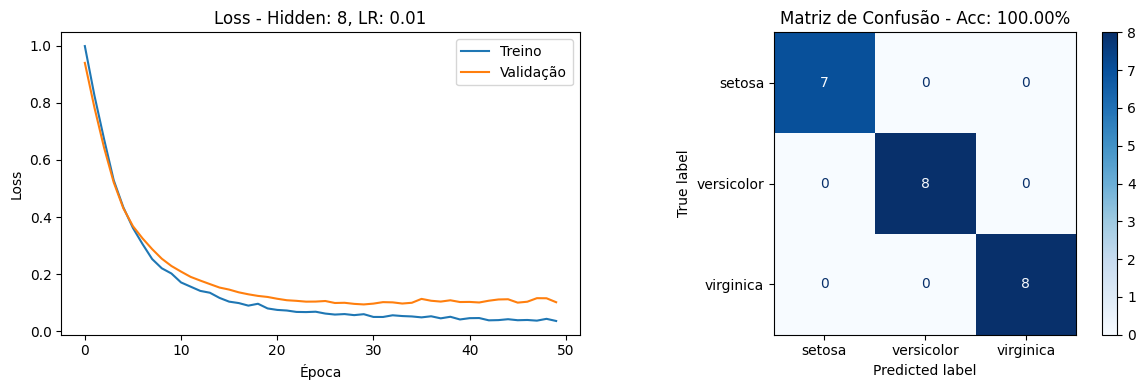

Treinando configuração: {'hidden_dim': 16, 'lr': 0.01, 'epochs': 50}


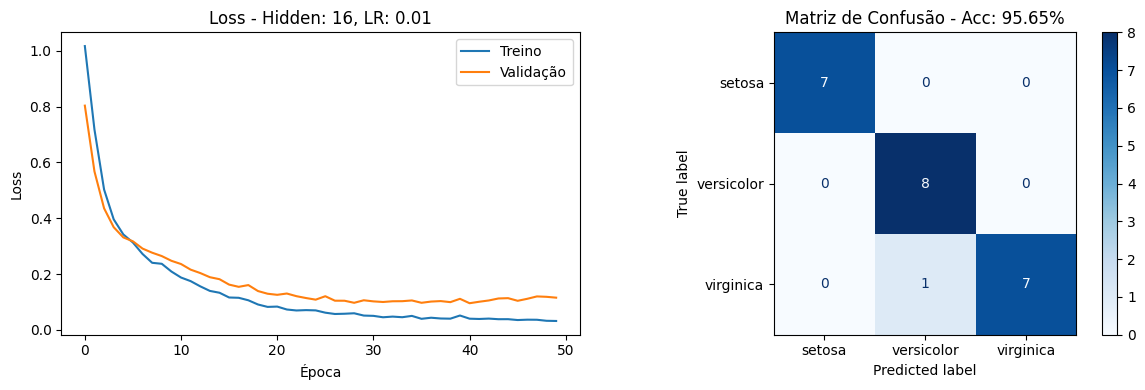

Treinando configuração: {'hidden_dim': 32, 'lr': 0.01, 'epochs': 50}


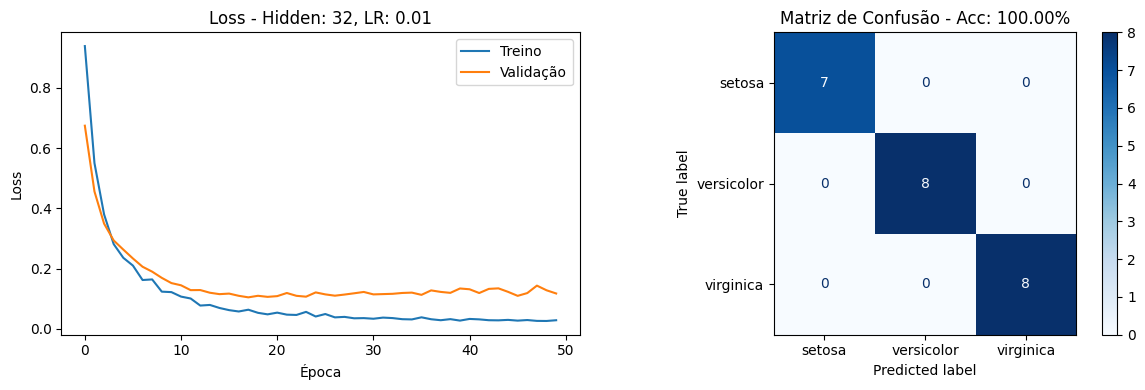

Treinando configuração: {'hidden_dim': 16, 'lr': 0.001, 'epochs': 100}


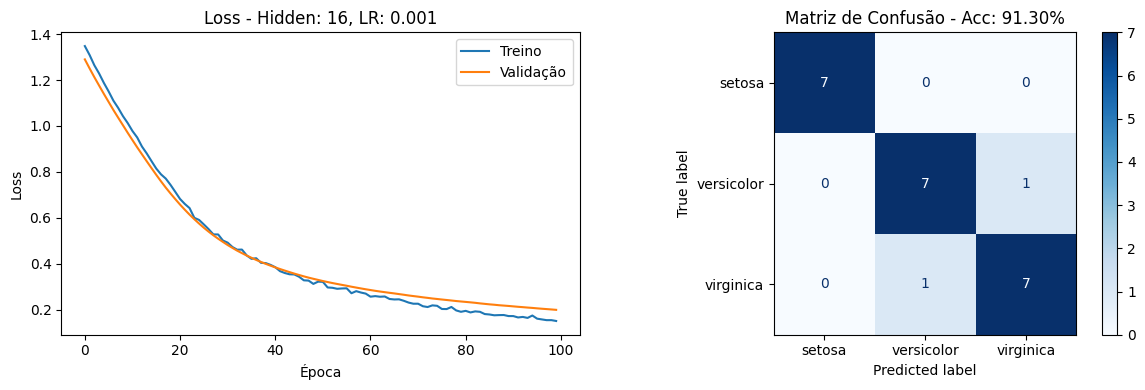


=== Relatório Final de Configurações ===


,Hidden Dim,Learning Rate,Epochs,Test Accuracy (%)
0,8,0.010,50,100.000000
1,16,0.010,50,95.652174
2,32,0.010,50,100.000000
3,16,0.001,100,91.304348


In [18]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Configurações para testar
configs = [
    {'hidden_dim': 8, 'lr': 0.01, 'epochs': 50},
    {'hidden_dim': 16, 'lr': 0.01, 'epochs': 50},
    {'hidden_dim': 32, 'lr': 0.01, 'epochs': 50},
    {'hidden_dim': 16, 'lr': 0.001, 'epochs': 100},
]

results = []

for conf in configs:
    print(f"Treinando configuração: {conf}")
    model, t_loss, v_loss = train_model(conf['hidden_dim'], conf['lr'], conf['epochs'], train_loader, val_loader)
    acc, y_true, y_pred = evaluate_model(model, test_loader)
    
    results.append({
        'Hidden Dim': conf['hidden_dim'],
        'Learning Rate': conf['lr'],
        'Epochs': conf['epochs'],
        'Test Accuracy (%)': acc
    })
    
    # Plotar losses para cada config
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # Gráfico de Perda
    ax[0].plot(t_loss, label='Treino')
    ax[0].plot(v_loss, label='Validação')
    ax[0].set_title(f"Loss - Hidden: {conf['hidden_dim']}, LR: {conf['lr']}")
    ax[0].set_xlabel('Época')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    
    # Matriz de Confusão
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
    disp.plot(cmap=plt.cm.Blues, ax=ax[1])
    ax[1].set_title(f"Matriz de Confusão - Acc: {acc:.2f}%")
    
    plt.tight_layout()
    plt.show()

# Criar DataFrame com relatório final
df_results = pd.DataFrame(results)
print("\n=== Relatório Final de Configurações ===")
display(df_results)